# ML with Keras : neural networks and deep learning

Keras is a high-level deep learning library written in Python. It provides a user-friendly and intuitive interface for building and training neural networks. One of the key features of Keras is its ability to work with different backend engines, such as [TensorFlow](https://www.tensorflow.org/), [JAX](https://jax.readthedocs.io/en/latest/) and [PyTorch](https://pytorch.org/).

**Architecture.** It offers a wide range of pre-defined layers, including `convolutional layers`, `recurrent layers`, and `dense layers`, which can be easily stacked together to create complex network architectures. It also provides a variety of `loss functions`, `optimizers`, and `metrics` for training and evaluating models.

**Artificial neural network (ANN)** is a computational model inspired by the biological neural networks in the brain. It is a machine learning algorithm that can be trained to recognize patterns and make predictions based on input data. We will be working with the `feedforward neural network`, which are basically directed acyclic graphs. The networks consist of interconnected nodes, called `artificial neurons` or `units`, organized into `layers`. There is the `input` and `output` layers and in between them possibly one or more `hidden` layers.



## What is a neural network?

<img src="images/slp_mlp.png" alt="Neural network diagram" width="800">


SLP is the simplest feedforward neural network. It can solve various logical or classification problems. A single **Dense layer** computes

$$output = \sigma(\mathbf{W}\mathbf{x} + \mathbf{b})$$

where $\mathbf{W}$ and $\mathbf{b}$ are learned parameters and $\sigma$ is an **activation function** (identity, ReLU, tanh, sigmoid, softmax, ...).

- With $\sigma$ = identity and one output unit: this is **linear regression**.
- With $\sigma$ = sigmoid: this is **logistic regression**.
- Stack two such layers with a *nonlinear* $\sigma$ in between → a **multilayer perceptron (MLP)**.


In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
# np.random.seed(0)

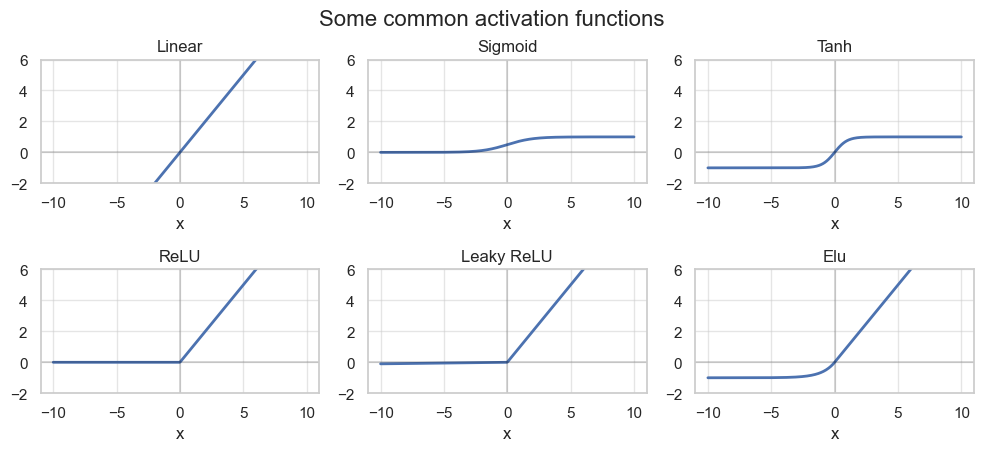

In [2]:
# Input range
x = np.linspace(-10, 10, 400)
x_ = np.linspace(-4, 4, 10)
#softmax = keras.layers.Softmax()

# Define activation functions
def linear(x): return x
def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x): return np.tanh(x)
def relu(x): return np.maximum(0, x)
def leaky_relu(x, alpha=0.01): return np.where(x < 0, alpha * x, x)
def elu(x, alpha=1.0): return np.where(x < 0, alpha * (np.exp(x) - 1), x )
#def softmax(x): return np.exp(x)/sum(np.exp(x))

# Dictionary of functions to plot
activations = {
    "Linear": linear,
    "Sigmoid": sigmoid,
    "Tanh": tanh,
    "ReLU": relu,
    "Leaky ReLU": leaky_relu,
    "Elu" : elu
}

# Plotting
plt.figure(figsize=(10, 6))
for i, (name, func) in enumerate(activations.items(), 1):
    plt.subplot(3, 3, i)
    plt.plot(x, func(x), linewidth=2)
    plt.title(name)
    plt.grid(True)
    plt.xlabel('x')
    plt.axhline(0, color='black', linewidth=0.2)
    plt.axvline(0, color='black', linewidth=0.2)
    plt.ylim(-2, 6)

plt.tight_layout()
plt.suptitle("Some common activation functions", fontsize=16, y=1.02)
plt.show()

1. Linear - linear output (no activation function).
2. Sigmoid — binary classification output (one neuron giving a probability).
3. Tanh — used in RNNs/LSTMs for the cell-state transformations
4. ReLU — default for hidden layers in MLPs and CNNs
5. Leaky ReLU — allow negative inputs to pass through with a small slope
6. ELU — exponential linear unit, similar to ReLU but with negative values

See also [Keras layer activation](https://keras.io/api/layers/activations/) for more.

---
# 1. From Linear models to multi-layer perceptrons (MLP)

## Scikit-learn: the polynomial example

We generate $y = 2x^2 - 5x + 3 + \varepsilon$ and fit it two ways. First, the classical recipe: build polynomial features, fit a linear regression.

**Generate X, y:**

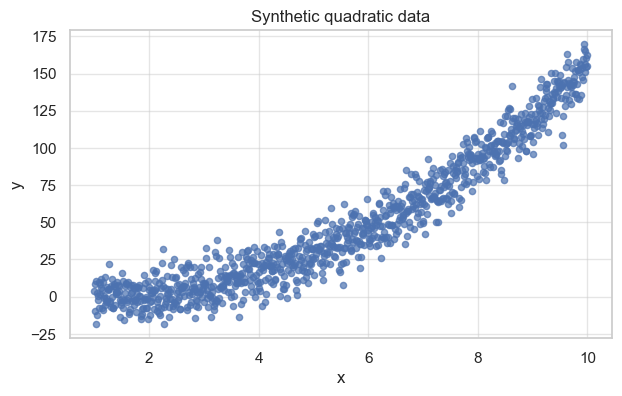

In [3]:
def poly_gen(rng_=(1, 10), size=100, seed=42):
    """y = 2x^2 - 5x + 3 + noise"""
    s, e = rng_
    rng = np.random.default_rng(seed)
    X = np.linspace(s, e, size).reshape(-1, 1)
    y = 2 * X**2 - 5 * X + 3 + rng.normal(s, e, (size, 1))
    return X, y

X, y = poly_gen(size=1000)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X, y, s=20, alpha=0.7)
ax.set(xlabel='x', ylabel='y', title='Synthetic quadratic data')
plt.show()

**Model, a linear regression with polynomial features:**

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Generate data
X, y = poly_gen(seed=None, size=1000)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# PolynomialFeatures + LinearRegression
poly = make_pipeline(PolynomialFeatures(degree=2, include_bias=False),
                     LinearRegression()).fit(X_train, y_train)


# Approximation
lr = poly[-1]             # last step: LinearRegression
[[deg1, deg2]] = lr.coef_ # coefficients of the linear model [x,x^2]
print(f"equation: y = {deg1:.2f}x^2 + {deg2:.2f}x + 3")
print(f"R^2 test : {poly.score(X_test,  y_test ):.3f}")


equation: y = -5.32x^2 + 2.00x + 3
R^2 test : 0.958


`PolynomialFeatures` *gives the model `[x, x²]` as input*. The true target is a linear combination of those two columns plus noise.


**Exercise.** Fit the same polynomial model but without using the `pipeline`.

## Keras NN API

```
from keras import Sequential              # model
from keras.layers import Input, Dense     # layers

model = Sequential([
    Input(shape=(n_features,)),           # input layer
    Dense(units=16, activation='relu'),   # hidden layer
    ...                                   # more hidden layers
    Dense(units=m_targets, activation=?)  # output layer
])

model.compile(optimizer='adam',            # how to update weights
              loss='mse',                  # what to minimise
              metrics=['mae'])             # what to log, e.g. mean absolute error

history = model.fit(X, y,                  # train the model on (X, y)
                    epochs=100,            # how many epochs to train for
                    batch_size=8,          # how many samples per gradient step
                    validation_split=0.2)  # how to split the validation set
```

Three things to remember:

| Line | What it does |
|------|--------------|
| `Sequential([...])` | Stacks layers in order. Each layer's output feeds the next. |
| `compile(...)` | Picks the **optimizer** (how to update weights), the **loss** (what to minimise), and **metrics** (what to log). |
| `fit(...)` | Runs stochastic gradient descent. Returns a `history` object with per-epoch logs. |

## First NN — Single Dense layer is linear regression

We'll train a one-unit, no-activation Keras model on a linear dataset and recover the slope and intercept.
The linear model is $y = 2 + 2.5x + \varepsilon$,


In [5]:
from keras import Sequential
from keras import optimizers
from keras.layers import Input, Dense

# Generate data : 200 points in [-3, 3], noise = 0.3 with  y = 2.5x + 2.0 + noise
rng = np.random.default_rng(0)
Xl = rng.uniform(-3, 3, size=(200, 1))
yl = 2.5 * Xl + 2.0 + rng.normal(0, 0.3, size=(200, 1))

# ML : LinearRegression
lm = LinearRegression().fit(Xl, yl)

# NN
lin_nn = Sequential([
                Input(shape=(1,), name='input'),
                Dense(1, activation=None, name='output')
         ])
lin_nn.compile(optimizer='SGD', loss='mse')   # default learning_rate=0.001
# lin_nn.compile(optimizer=optimizers.Adam(learning_rate=0.1), loss='mse')

# train
lin_nn.fit(Xl, yl, epochs=50, batch_size=16, verbose=0)
W, b = lin_nn.layers[0].get_weights()

# print
pd.DataFrame({'slope': [W[0,0], lm.coef_[0,0]], 'intercept': [b[0], lm.intercept_[0]]},
             index=['NN','ML:LM'])

,slope,intercept
NN,2.488476,1.977962
ML:LM,2.487349,1.976183


**Summary**

In [6]:
lin_nn.summary() # see also lin_nn.optimizer.get_config() for more on the optimiser

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ output (Dense)                  │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## From SLP to MLP — solving the polynomial with an NN

Now the polynomial $y = 2x^2 - 5x + 3 + \varepsilon$. Without `PolynomialFeatures`, we need a *nonlinear* hidden layer. We'll **standardise** X and y first (this matters — we'll see why later in this lecture).


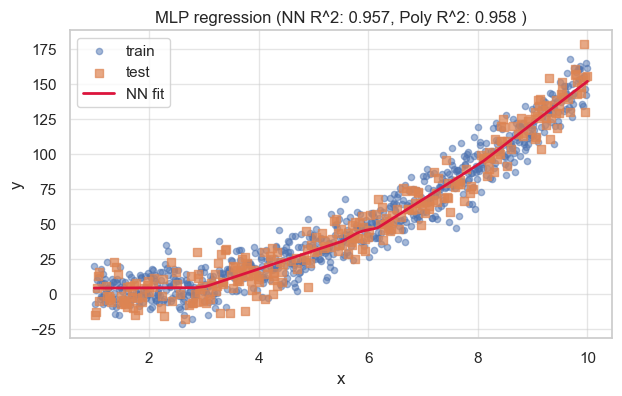

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# standardise X and y
sx, sy = StandardScaler(), StandardScaler()
X_tr_s = sx.fit_transform(X_train); X_te_s = sx.transform(X_test)
y_tr_s = sy.fit_transform(y_train); y_te_s = sy.transform(y_test)

# NN
mlp = Sequential([
    Input(shape=(1,)),
    Dense(16, activation='relu', name="h1"), # non-linearity
    Dense(1,  activation=None, name="out"),
])

# train
mlp.compile(optimizer='adam', loss='mse', metrics=['mae'])
h = mlp.fit(X_tr_s, y_tr_s, epochs=100, batch_size=8,
            validation_split=0.2, verbose=0)

# back-transform predictions for plotting
X_grid   = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_grid_p = sy.inverse_transform(mlp.predict(sx.transform(X_grid), verbose=0))

# compare to ML
y_pred_test = sy.inverse_transform(mlp.predict(X_te_s, verbose=0))

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X_train, y_train, s=20, alpha=0.5, label='train')
ax.scatter(X_test,  y_test,  s=30, alpha=0.7, marker='s', label='test')
ax.plot(X_grid, y_grid_p, color='crimson', lw=2, label='NN fit')
ax.legend(); ax.set(xlabel='x', ylabel='y',
                    title=f'MLP regression (NN R^2: {r2_score(y_test, y_pred_test):.3f}, Poly R^2: {poly.score(X_test, y_test):.3f} )')
plt.show()

In [8]:
mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149 (600.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 100 (404.00 B)

- 49 = model's actual learning capacity
- +2 = optimiser bookkeeping (iterations counter + lr).
- +98 appears later, once fit() allocates Adam's running statistics.

## Training mechanism

- **Optimizer.** `adam` is an Stochastic gradient descent (SGD) optimiser with per-parameter adaptive learning rate. Plain `SGD` works too, but you'll often need to tune the learning rate by hand.
- **Batch size.** Number of samples per gradient step. Small batches → noisier but more frequent updates. Common values: 8–128 for tabular, 32–256 for images.
- **Epochs.** One epoch = one pass through the training set. Too few → underfit. Too many → overfit.

See [Scikit-learn ](https://scikit-learn.org/stable/modules/linear_model.html#ordinary-least-squares) for linear models and [Keras optimisers](https://keras.io/api/optimizers/).

---
# 2) NN performance

## The `history` object

`model.fit(...)` returns a `History`. The dict `history.history` has one list per metric, one entry per epoch:

In [9]:
hist_df = pd.DataFrame(h.history)
hist_df['epoch'] = hist_df.index + 1
hist_df.head()

,loss,mae,val_loss,val_mae,epoch
0,0.641469,0.666277,0.347410,0.487551,1
1,0.263348,0.428736,0.132240,0.299345,2
2,0.129160,0.298180,0.061448,0.194919,3
3,0.086902,0.235134,0.044173,0.165744,4
4,0.075270,0.216525,0.040895,0.161495,5


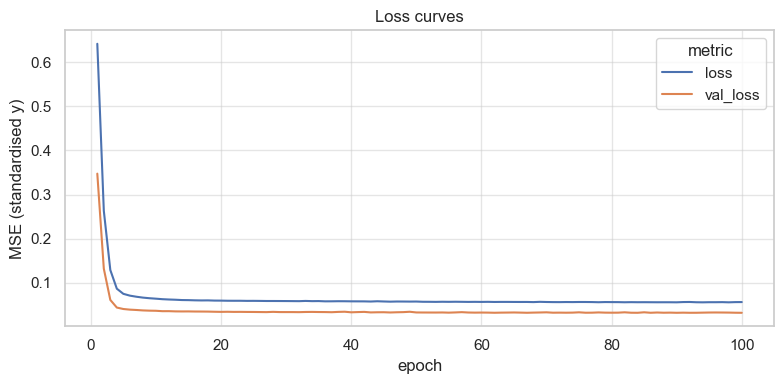

In [10]:
long = hist_df.melt(id_vars='epoch', var_name='metric', value_name='value')
fig, ax = plt.subplots(figsize=(8, 4)) #
sns.lineplot(data=long[long['metric'].isin(['loss', 'val_loss'])],
             x='epoch', y='value', hue='metric', ax=ax)
ax.set(title='Loss curves', ylabel='MSE (standardised y)')
plt.tight_layout()
plt.show()

## Reading the curves — overfitting

- **Both losses decreasing together** → still learning. Train longer.
- **Train ↓ and val ↑** → overfitting. Stop earlier or regularise.
- **Both flat and high** → underfitting. More capacity, more epochs, better features, or check scaling.

A useful summary statistic is the **generalization gap** $\text{val\_loss} - \text{loss}$.

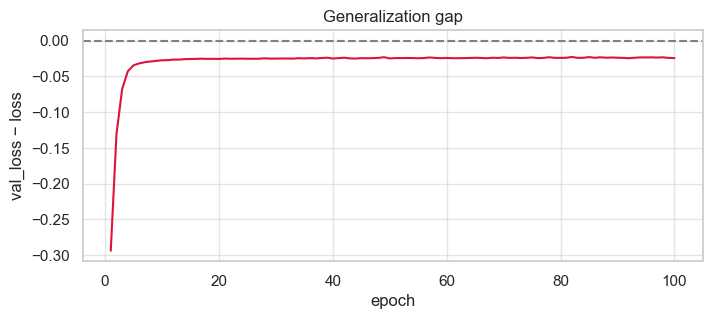

In [11]:
hist_df['gap'] = hist_df['val_loss'] - hist_df['loss']
fig, ax = plt.subplots(figsize=(8, 3))
sns.lineplot(data=hist_df, x='epoch', y='gap', ax=ax, color='crimson')
ax.axhline(0, ls='--', color='gray')
ax.set(title='Generalization gap', ylabel='val_loss − loss')
plt.show()

## When the NN fails — checklist

1. **Inputs / targets not scaled.**
   - `tanh` and `sigmoid` saturate when $|Wx+b| \gg 0$ — gradients ≈ 0, learning stalls.
   - MSE on large $y$ values produces huge gradients — optimiser oscillates or diverges.
   - **Fix:** `StandardScaler` X (and y, for regression).
2. **Wrong optimizer or learning rate.**
   - `SGD` with default learning_rate is often too slow. Try `'adam' (Adaptive Moment Estimation)` first.
3. **Wrong capacity.**
   - Too few units → underfit. Too many on a small dataset → overfit.
4. **Validation split with ordered data.**
   - `validation_split=0.4` takes the **last 40 % without shuffling**. If X is sorted, val and train have different distributions.
   - **Fix:** shuffle before `fit`, or pass `validation_data=(X_val, y_val)` explicitly.

| Task | Output layer | Loss | Metrics |
|---|---|---|---|
| Regression | `Dense(1, None)` | `mse` | `mae`, `R2Score()` |
| Binary classification | `Dense(1, 'sigmoid')` | `binary_crossentropy` | `accuracy`, `AUC` |
| Multi-class (one-hot $y$) | `Dense(k, 'softmax')` | `categorical_crossentropy` | `accuracy` |
| Multi-class (integer $y$) | `Dense(k, 'softmax')` | `sparse_categorical_crossentropy` | `accuracy` |

Use `accuracy` for *classification* and  $R^2$ or MAE for *regression*.

## Classification — Iris with an MLP

Three species, four features. A single hidden-layer MLP with softmax output is more than enough.

In [12]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import keras

# Load the Iris dataset
iris = load_iris()
X_i, y_i = iris.data, iris.target

# Split the data into train and test sets
X_tr, X_te, y_tr, y_te = train_test_split(
    X_i, y_i, test_size=0.3, random_state=42, stratify=y_i)

# Standardise the features
scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr); X_te = scaler.transform(X_te)

# One-hot encode the target
y_tr_oh = keras.utils.to_categorical(y_tr, 3)
y_te_oh = keras.utils.to_categorical(y_te, 3)

# Build the model
clf = Sequential([
    Input(shape=(4,), name= "input"),               # input layer ; 4 features
    Dense(16, activation='relu', name="h1"),        # hidden layer
    Dense(3,  activation='softmax', name="output"), # output layer ; 3 classes
])

# Compile the model
# 1)
optimiser_default = keras.optimizers.Adam()
# 2)
optimiser_01 = keras.optimizers.Adam(learning_rate=0.1)

#
clf.compile(optimizer=optimiser_01,          # Adam optimiser
            loss='categorical_crossentropy', # softmax loss ; multiclass
            metrics=['accuracy'])            # accuracy

# Train the model
h_clf = clf.fit(X_tr, y_tr_oh, epochs=100, batch_size=10,
                validation_split=0.2, verbose=0)

# Evaluate the model
loss_te, acc_te = clf.evaluate(X_te, y_te_oh, verbose=0)

print(f"Test loss     : {loss_te:.3f}") # No fixed upper bound;
                                        # values around 0.05–0.3 are typical for
                                        # well-trained Iris models.
print(f"Test accuracy : {acc_te:.3f}")  #


Test loss     : 0.222
Test accuracy : 0.911


**Explanation**

- `loss` is the loss function used for training.
- `metrics` is a list of metrics to be evaluated by the model during training and testing.


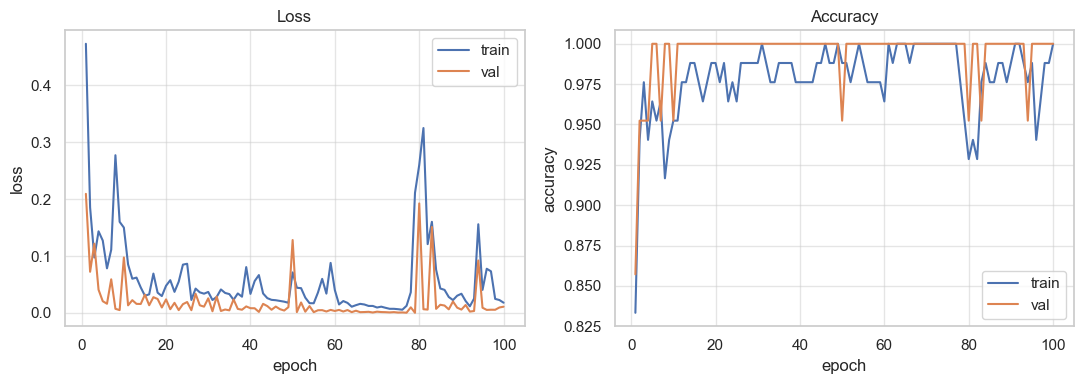

In [14]:
h_df = pd.DataFrame(h_clf.history)
h_df['epoch'] = h_df.index + 1
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.lineplot(data=h_df, x='epoch', y='loss',     label='train', ax=axes[0])
sns.lineplot(data=h_df, x='epoch', y='val_loss', label='val',   ax=axes[0])
axes[0].set(title='Loss')
sns.lineplot(data=h_df, x='epoch', y='accuracy',     label='train', ax=axes[1])
sns.lineplot(data=h_df, x='epoch', y='val_accuracy', label='val',   ax=axes[1])
axes[1].set(title='Accuracy')
plt.tight_layout(); plt.show()

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred = clf.predict(X_te, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_te, y_pred)
print("Confusion matrix:\n---")
print(pd.DataFrame(cm, columns=iris.target_names, index=iris.target_names))
print("---")
print(classification_report(y_te, y_pred, target_names=iris.target_names))

Confusion matrix:
---
            setosa  versicolor  virginica
setosa          15           0          0
versicolor       0          14          1
virginica        0           3         12
---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



---
# Exercise



## 1) Polynomial regression with a neural network

Use an updated version of the `poly_gen` function with different polynomial degrees:

1. **Baseline.** Fit `PolynomialFeatures(degree=???) + LinearRegression`. Report $R^2$ on train and test.
2. **Naive NN.** Train a Keras MLP with one hidden layer of 16 ReLU units on the **raw** `(X, y)`. Plot the fit on top of the data and report $R^2$ on the test set.
3. **Scaled NN.** Standardise both `X` and `y` with `StandardScaler`. Train the same structure. Compare $R^2$ to step 2 and to the baseline.
4. Pick **one** axis to vary and report a small table of test $R^2$ and final `val_loss`:
   - hidden units ∈ {3, 16, 64}, **or**
   - optimizer ∈ {SGD, Adam}, **or**
   - activation ∈ {tanh, relu}.
5. **Reflect.** Which factor mattered most?

## 2) MLP classifier on Iris

1. **Load and inspect.** `from sklearn.datasets import load_iris`. Plot two feature pairs coloured by class (seaborn `scatterplot`).
2. **Preprocess.** Stratified 70/30 train/test split, `StandardScaler` on the features, one-hot encode the target.
3. **MLP.** Build `Dense(16, relu) → Dense(3, softmax)`. Compile with `categorical_crossentropy` and `accuracy`. Train for 200 epochs, `batch_size=8`, `validation_split=0.2`.
4. **Curves.** Plot loss and accuracy vs epoch (train and val).
5. **Evaluate.** Report test accuracy and a confusion matrix. Compare to a `LogisticRegression` baseline.
6. **Vary one thing.** Either (a) change the hidden width to 4 and to 64, or (b) remove standardisation. Note what happens to the curves.
7. **Reflect.** Was the MLP better than logistic regression on Iris? Why or why not?


## 3) MNIST with a small MLP (optional)

**MNIST** is a 70 000-image dataset of hand-written digits (28 × 28 grayscale, labelled 0–9). Each digit image (28x28) is a 784 vector.

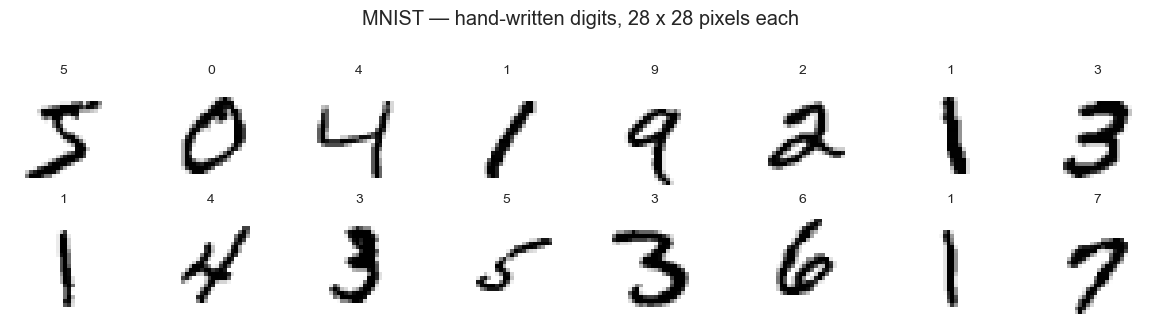

In [16]:
from keras.datasets import mnist
(X_mn, y_mn), _ = mnist.load_data()

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, img, label in zip(axes.ravel(), X_mn[:16], y_mn[:16]):
    ax.imshow(img, cmap='gray_r')
    ax.set_title(int(label), fontsize=10)
    ax.axis('off')
plt.suptitle('MNIST — hand-written digits, 28 x 28 pixels each', y=1.02)
plt.tight_layout(); plt.show()



1. **Load.** `from keras.datasets import mnist; (X_tr, y_tr), (X_te, y_te) = mnist.load_data()`. Print the shapes.
2. **Preprocess.** Flatten each image to a length-784 vector, cast to `float32`, scale to `[0, 1]` (divide by 255). One-hot encode the labels with `keras.utils.to_categorical`.
3. **Model.** Build a small MLP: `Dense(128, relu) → Dense(10, softmax)`. Compile with `categorical_crossentropy` and `accuracy`.
4. **Train.** 10 epochs, `batch_size=128`, `validation_split=0.1`. Report training time and test accuracy.
5. **Curves and errors.** Plot loss and accuracy curves. Pick 8 misclassified test images and display them with predicted vs. true labels.
6. **Vary one thing.** Try one of: (a) skip the `/255` normalisation, (b) replace `relu` with `sigmoid`, or (c) double the hidden width to 256. Note the effect on the curves.
7. **Reflect.** What changed compared to Iris in terms of training time, accuracy, and where the model makes mistakes?